# BirdCLEF 2026 Dataset - Preliminary Analysis

This notebook performs an initial exploratory analysis of the BirdCLEF 2026 data in the local `birdclef-2026/` folder.

Main goals:
- Validate available files and basic schema
- Understand label distribution and imbalance
- Inspect taxonomy and class composition
- Analyze soundscape labels and timing patterns
- Check geospatial coverage in the training metadata
- Produce practical next steps for modeling

In [36]:
import numpy as np
import geopandas as gpd
import geodatasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import MultiLabelBinarizer

import librosa
import librosa.display

from pathlib import Path
from birdclef_2026_ml.notebook_utils import init_notebook
init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
project_root = Path.cwd().parent
data_root = project_root / 'birdclef-2026'

paths = {
    # classes sounds : metadata + audio
    'train_csv': data_root / 'train.csv', 
    'train_audio_dir': data_root / 'train_audio',

    # soundscapes : metadata + audio
    'soundscape_labels_csv': data_root / 'train_soundscapes_labels.csv',
    'train_soundscapes_dir': data_root / 'train_soundscapes',
    
    # Hierarchy 
    'taxonomy_csv': data_root / 'taxonomy.csv',    
    
    # Test dataset 
    'test_soundscapes_dir': data_root / 'test_soundscapes', 
    'sample_submission_csv': data_root / 'sample_submission.csv',
}

In [3]:
train = pd.read_csv(paths['train_csv'])
taxonomy = pd.read_csv(paths['taxonomy_csv'])
soundscape_labels = pd.read_csv(paths['soundscape_labels_csv'])
sample_submission = pd.read_csv(paths['sample_submission_csv'])


print('train shape:', train.shape)
print('taxonomy shape:', taxonomy.shape)
print('soundscape_labels shape:', soundscape_labels.shape)
print('sample_submission shape:', sample_submission.shape)

display(train.head())
display(taxonomy.head())
display(soundscape_labels.head())
display(sample_submission.head())

train shape: (35549, 15)
taxonomy shape: (234, 5)
soundscape_labels shape: (1478, 4)
sample_submission shape: (3, 235)


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia


,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380


,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
2,BC2026_Test_0001_S05_20250227_010002_15,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274


#### `train`

Train rows with valid coordinates: 35549 / 35549
Latitude range: (np.float64(-54.8574), np.float64(69.578))
Longitude range: (np.float64(-159.6556), np.float64(175.3239))


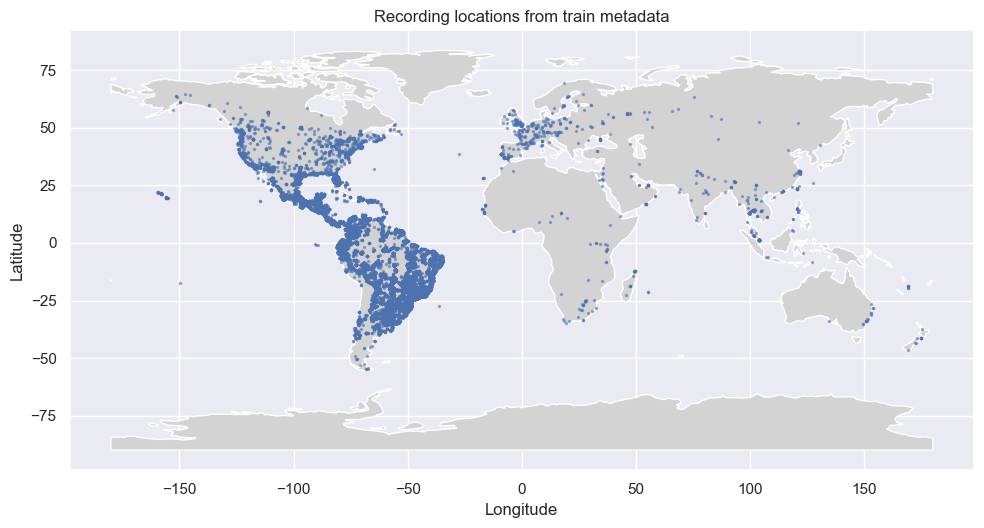

In [41]:
geo = train[['latitude', 'longitude']].dropna()
gdf = gpd.GeoDataFrame(
    geo,
    geometry=gpd.points_from_xy(geo.longitude, geo.latitude),
    crs="EPSG:4326"
)

# World map
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

print('Train rows with valid coordinates:', len(geo), '/', len(train))
print('Latitude range:', (geo['latitude'].min(), geo['latitude'].max()))
print('Longitude range:', (geo['longitude'].min(), geo['longitude'].max()))

fig, ax = plt.subplots(figsize=(10, 7))
world.plot(ax=ax, color="lightgray")
gdf.plot(ax=ax, markersize=2, alpha=0.5)

plt.title('Recording locations from train metadata')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()

##### `soundscape_labels`

This is what will be given in the test dataset

In [4]:
mlb = MultiLabelBinarizer() # multi-hot encoding
soundscape_labels["primary_label_list"] = soundscape_labels["primary_label"].str.split(";")
Y = mlb.fit_transform(soundscape_labels["primary_label_list"])

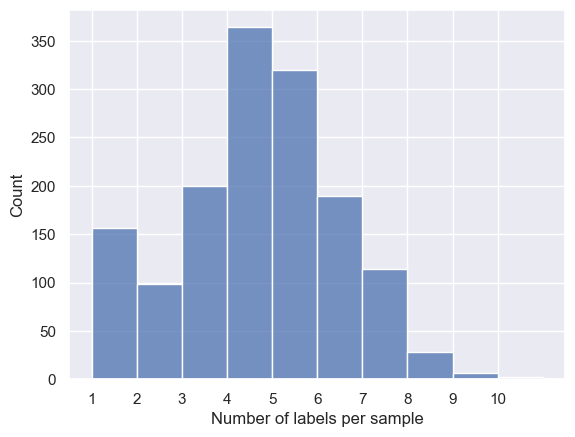

In [5]:
counts = Y.sum(axis=1)
mn, mx = counts.min(), counts.max()
bins = np.arange(mn, mx + 2) 
sns.histplot(counts, bins=bins)
plt.xticks(np.arange(mn, mx + 1)) 
plt.xlabel("Number of labels per sample")
plt.ylabel("Count")
plt.show()

Number of classes in soundscapes: 75
Number of classes in train: 206


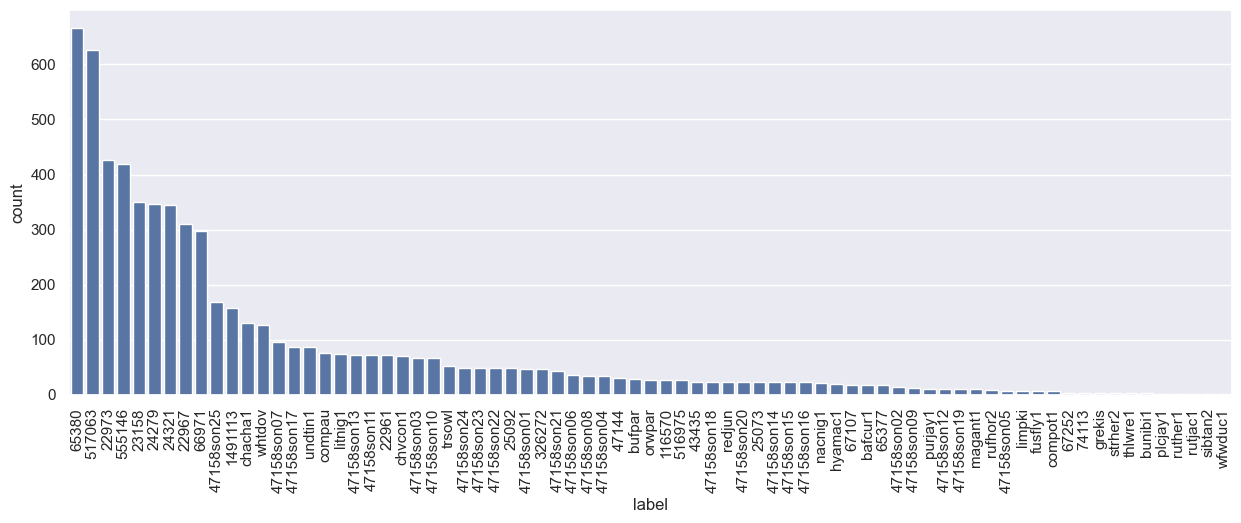

In [14]:
print("Number of classes in soundscapes:", len(mlb.classes_))
print("Number of classes in train:",  train["primary_label"].nunique())

# How much each class appears
df = pd.DataFrame(data={"label":mlb.classes_, "count":Y.sum(axis=0)}).sort_values("count", ascending=False)
plt.figure(figsize=(15, 5))
sns.barplot(data=df, x="label", y="count")
plt.xticks(rotation=90);

<Axes: >

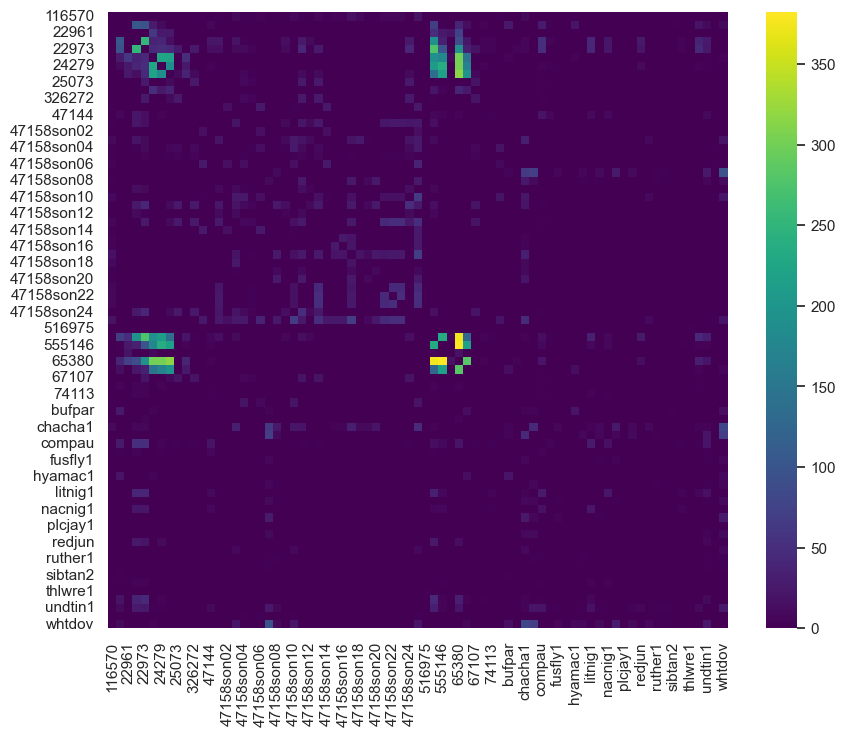

In [26]:
# Cooccurence matrix
C = Y.T @ Y
np.fill_diagonal(C, val=0)
df = pd.DataFrame(data=C, index=mlb.classes_, columns=mlb.classes_)
fig=plt.figure(figsize=(10, 8))
sns.heatmap(data=df, cmap="viridis")

<Axes: >

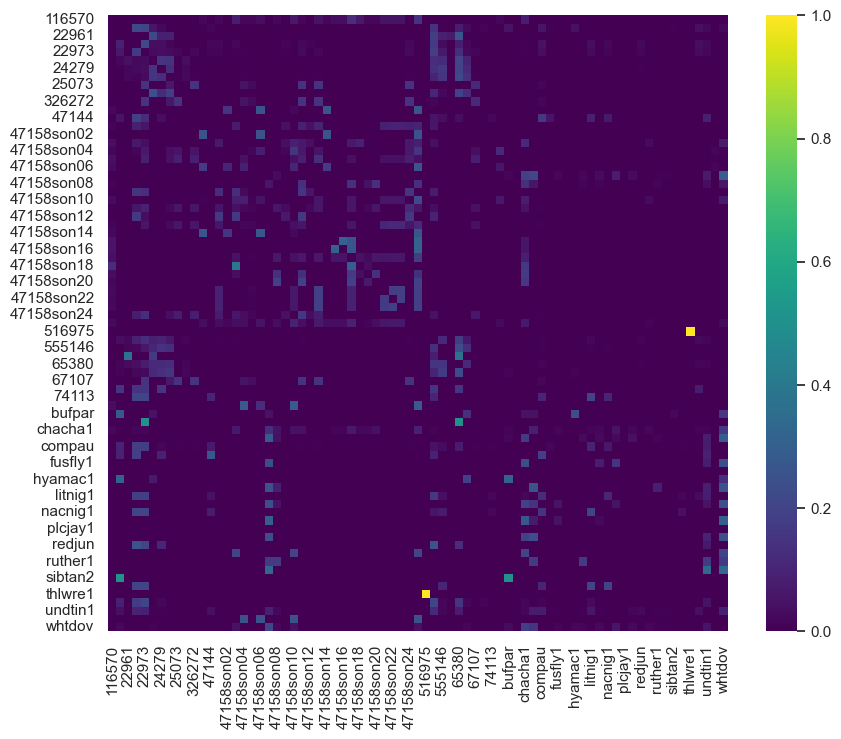

In [29]:
# Cooccurence matrix, normalized per row -> should be read per row and interpreted as a probability distribution
C = Y.T @ Y
np.fill_diagonal(C, val=0)
D = C.sum(axis=1).reshape(-1, 1)
C_normalized = np.divide(C, D, where=D != 0, out=np.zeros_like(C, dtype=float))

df = pd.DataFrame(data=C_normalized, index=mlb.classes_, columns=mlb.classes_)
fig=plt.figure(figsize=(10, 8))
sns.heatmap(data=df, cmap="viridis")

#### `taxonomy`

In [4]:
fig = px.sunburst(
    taxonomy,
    path=["class_name", "scientific_name"],  # hierarchy
    values=None  # counts automatically
)

fig.show()

***

In [67]:
summary_rows = []
for name, df in [
    ('train', train),
    ('taxonomy', taxonomy),
    ('soundscape_labels', soundscape_labels),
]:
    summary_rows.append({
        'table': name,
        'rows': len(df),
        'columns': df.shape[1],
        'duplicate_rows': int(df.duplicated().sum()),
        'missing_cells': int(df.isna().sum().sum()),
    })

quality_summary = pd.DataFrame(summary_rows)
quality_summary

,table,rows,columns,duplicate_rows,missing_cells
0,train,35549,15,0,0
1,taxonomy,234,5,0,0
2,soundscape_labels,1478,4,739,0


In [ ]:
label_counts = train['primary_label'].value_counts().rename_axis('primary_label').reset_index(name='n_samples')

train_with_class = train.merge(
    taxonomy[['primary_label', 'target_name']],
    on='primary_label',
    how='left'
)
print(train_with_class)
class_counts = train_with_class['target_name'].fillna('Unknown').value_counts().sort_values(ascending=False)

print('Number of unique primary labels in train:', train['primary_label'].nunique())
print('Number of unique primary labels in taxonomy:', taxonomy['primary_label'].nunique())
print('Labels in train missing from taxonomy:', train_with_class['target_name'].isna().sum())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_k = 20
top_labels = label_counts.head(top_k).iloc[::-1]
axes[0].barh(top_labels['primary_label'], top_labels['n_samples'])
axes[0].set_title(f'Top {top_k} labels by number of recordings')
axes[0].set_xlabel('Count')

class_counts.plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Distribution by target_name')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

label_counts.head(10)

KeyError: "['target_name'] not in index"

In [ ]:
def parse_secondary_labels(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    text = str(value).strip()
    if text in {'', '[]'}:
        return []
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return [str(x) for x in parsed]
    except Exception:
        pass
    # Fallback for unexpected delimiter formatting
    cleaned = text.strip('[]')
    if not cleaned:
        return []
    return [x.strip().strip("'").strip('\"') for x in cleaned.split(',') if x.strip()]

secondary_series = train['secondary_labels'].apply(parse_secondary_labels)
secondary_exploded = secondary_series.explode().dropna()

print('Rows with at least one secondary label:', int((secondary_series.str.len() > 0).sum()))
print('Unique secondary labels:', secondary_exploded.nunique())

secondary_exploded.value_counts().head(15).to_frame('count')

In [ ]:
# Compare metadata counts with physically present audio files per label directory
audio_dir = paths['train_audio_dir']
folder_counts = {}
if audio_dir.exists():
    for d in audio_dir.iterdir():
        if d.is_dir():
            folder_counts[d.name] = len(list(d.glob('*.ogg')))

audio_counts = (
    pd.Series(folder_counts, name='files_in_folder')
    .rename_axis('primary_label')
    .reset_index()
)

metadata_counts = train['primary_label'].value_counts().rename_axis('primary_label').reset_index(name='rows_in_train_csv')
coverage = metadata_counts.merge(audio_counts, on='primary_label', how='outer').fillna(0)
coverage[['rows_in_train_csv', 'files_in_folder']] = coverage[['rows_in_train_csv', 'files_in_folder']].astype(int)
coverage['difference'] = coverage['rows_in_train_csv'] - coverage['files_in_folder']

print('Total train rows:', int(coverage['rows_in_train_csv'].sum()))
print('Total audio files found:', int(coverage['files_in_folder'].sum()))
print('Labels with mismatch:', int((coverage['difference'] != 0).sum()))

coverage.sort_values('difference', key=np.abs, ascending=False).head(20)

In [ ]:
# The primary_label field in soundscape labels can contain multiple labels separated by ';'
soundscape_exploded = (
    soundscape_labels.assign(
        label_list=soundscape_labels['primary_label'].fillna('').str.split(';')
    )
    .explode('label_list')
    .rename(columns={'label_list': 'label'})
)
soundscape_exploded['label'] = soundscape_exploded['label'].astype(str).str.strip()
soundscape_exploded = soundscape_exploded[soundscape_exploded['label'] != '']

soundscape_label_counts = soundscape_exploded['label'].value_counts()

print('Soundscape segments:', len(soundscape_labels))
print('Expanded soundscape labels:', len(soundscape_exploded))
print('Unique soundscape labels:', soundscape_exploded['label'].nunique())

soundscape_label_counts.head(20).to_frame('count')

In [ ]:
# Parse timestamp from soundscape filename pattern: *_YYYYMMDD_HHMMSS.ogg
def extract_datetime_from_soundscape_filename(filename):
    match = re.search(r'_(\\d{8})_(\\d{6})\\.ogg$', str(filename))
    if not match:
        return pd.NaT
    dt_str = f"{match.group(1)} {match.group(2)}"
    return pd.to_datetime(dt_str, format='%Y%m%d %H%M%S', errors='coerce')

soundscape_time = soundscape_labels.copy()
soundscape_time['datetime'] = soundscape_time['filename'].apply(extract_datetime_from_soundscape_filename)
soundscape_time['hour'] = soundscape_time['datetime'].dt.hour

valid_hours = soundscape_time['hour'].dropna().astype(int)
print('Rows with parsed datetime:', len(valid_hours), '/', len(soundscape_time))

if len(valid_hours) > 0:
    plt.figure(figsize=(10, 4))
    valid_hours.value_counts().sort_index().plot(kind='bar', color='darkslateblue')
    plt.title('Soundscape segment count by hour of day')
    plt.xlabel('Hour')
    plt.ylabel('Segments')
    plt.tight_layout()
    plt.show()
else:
    print('No parseable timestamps found in soundscape filenames.')

In [ ]:
submission_label_cols = [c for c in sample_submission.columns if c != 'row_id']
taxonomy_labels = set(taxonomy['primary_label'].astype(str))
submission_labels = set(map(str, submission_label_cols))

print('Submission rows:', len(sample_submission))
print('Submission label columns:', len(submission_label_cols))
print('Labels in submission but not taxonomy:', len(submission_labels - taxonomy_labels))
print('Labels in taxonomy but not submission:', len(taxonomy_labels - submission_labels))

sample_submission.iloc[:3, :12]

## Preliminary Findings Template

After running all cells, summarize:
1. Which labels dominate the training data and how severe imbalance is.
2. Whether train metadata and audio folder counts are consistent.
3. If soundscape segments are concentrated in specific hours.
4. Coordinate coverage and whether any outliers look suspicious.
5. Any taxonomy/submission label mismatches that need preprocessing handling.

## Suggested Next Steps

- Create a reproducible preprocessing script to generate clean label mappings and split files.
- Build a stratified validation strategy that accounts for label imbalance and potential location/time leakage.
- Add lightweight audio-level EDA (duration, sample rate, amplitude stats, mel-spectrogram examples).
- Define a first baseline model (e.g., CNN on log-mel or pretrained audio encoder + linear head).